Estadísticas del índice compuesto:
count    348.00
mean       6.57
std        1.31
min        3.50
25%        5.67
50%        6.33
75%        7.50
max        9.83
Name: composite, dtype: float64


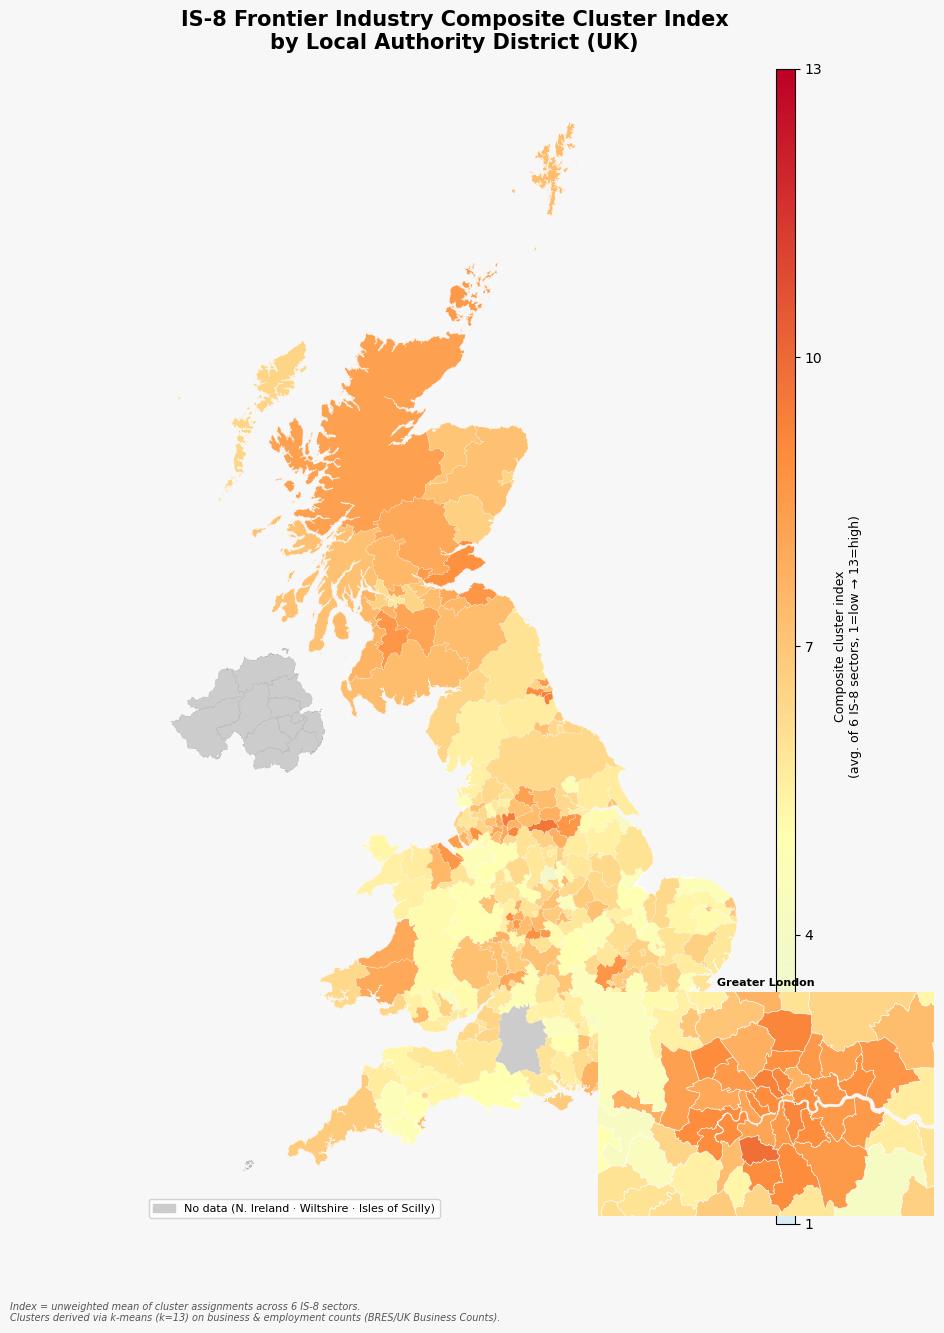

Guardado: lad_is8_composite_map.png


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

# ── 1. CARGAR DATOS ───────────────────────────────────────────────────────────
gdf = gpd.read_file("lad_is8_clusters_geo.gpkg")
gdf = gdf.to_crs(epsg=27700)  # British National Grid

SECTOR_COLS = [
    "Advanced Manufacturing", "Clean Energy", "Creative Industries",
    "Digital & Technologies", "Financial Services", "Life Sciences"
]

# ── 2. CALCULAR ÍNDICE COMPUESTO ──────────────────────────────────────────────
gdf["composite"] = gdf[SECTOR_COLS].mean(axis=1)

print("Estadísticas del índice compuesto:")
print(gdf["composite"].describe().round(2))

# ── 3. PALETA PERSONALIZADA ───────────────────────────────────────────────────
# Azul claro (cluster bajo) → amarillo → rojo oscuro (cluster alto)
cmap = LinearSegmentedColormap.from_list(
    "is8", ["#d9edf7", "#ffffb2", "#fd8d3c", "#bd0026"], N=256
)

# ── 4. INSET LONDRES ─────────────────────────────────────────────────────────
# Bounding box de Greater London en BNG (metros)
LONDON_BBOX = (490_000, 155_000, 565_000, 205_000)

# ── 5. FIGURA PRINCIPAL ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 15))
fig.patch.set_facecolor("#f7f7f7")
ax.set_facecolor("#cfe2f3")

# LADs sin datos en gris
gdf_nodata = gdf[gdf["composite"].isna()]
gdf_data   = gdf[gdf["composite"].notna()]

gdf_nodata.plot(ax=ax, color="#cccccc", edgecolor="#aaaaaa", linewidth=0.2)

# Mapa principal
gdf_data.plot(
    ax=ax,
    column="composite",
    cmap=cmap,
    vmin=1, vmax=13,
    edgecolor="white",
    linewidth=0.15,
    legend=False,
)

ax.set_title(
    "IS-8 Frontier Industry Composite Cluster Index\nby Local Authority District (UK)",
    fontsize=15, fontweight="bold", pad=14
)
ax.axis("off")

# ── 6. COLORBAR ───────────────────────────────────────────────────────────────
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
sm  = plt.cm.ScalarMappable(cmap=cmap,
                             norm=plt.Normalize(vmin=1, vmax=13))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Composite cluster index\n(avg. of 6 IS-8 sectors, 1=low → 13=high)",
               fontsize=9, labelpad=8)
cbar.set_ticks([1, 4, 7, 10, 13])

# ── 7. INSET ZOOM LONDRES ─────────────────────────────────────────────────────
ax_lon = fig.add_axes([0.62, 0.08, 0.28, 0.22])  # [left, bottom, width, height]
ax_lon.set_facecolor("#cfe2f3")

gdf_nodata.plot(ax=ax_lon, color="#cccccc", edgecolor="#aaaaaa", linewidth=0.3)
gdf_data.plot(
    ax=ax_lon,
    column="composite",
    cmap=cmap,
    vmin=1, vmax=13,
    edgecolor="white",
    linewidth=0.4,
    legend=False,
)
ax_lon.set_xlim(LONDON_BBOX[0], LONDON_BBOX[2])
ax_lon.set_ylim(LONDON_BBOX[1], LONDON_BBOX[3])
ax_lon.set_title("Greater London", fontsize=8, fontweight="bold", pad=4)
ax_lon.axis("off")

# Borde del inset
for spine in ax_lon.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#444444")
    spine.set_linewidth(1)

# ── 8. LEYENDA ────────────────────────────────────────────────────────────────
no_data_patch = mpatches.Patch(
    color="#cccccc",
    label="No data (N. Ireland · Wiltshire · Isles of Scilly)"
)
ax.legend(handles=[no_data_patch], loc="lower left", fontsize=8, framealpha=0.85)

# ── 9. NOTA METODOLÓGICA ──────────────────────────────────────────────────────
fig.text(
    0.13, 0.045,
    "Index = unweighted mean of cluster assignments across 6 IS-8 sectors.\n"
    "Clusters derived via k-means (k=13) on business & employment counts (BRES/UK Business Counts).",
    fontsize=7, color="#555555", style="italic"
)

plt.savefig("lad_is8_composite_map.png", dpi=180, bbox_inches="tight")
plt.show()
print("Guardado: lad_is8_composite_map.png")